# Tarun XGBoost Models

This notebook trains two XGBoost models on the engineered NYC yellow taxi dataset:

- congestion fee classification using `has_congestion_fee`
- trip duration regression using `trip_duration_min`

The workflow uses a stratified sample of 150,000 rows so the notebook stays reproducible and quick to rerun.


In [1]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier, XGBRegressor

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid", palette="deep")

SEED = 42
SAMPLE_SIZE = 150_000

DATA_PATH = Path("../../data/processed/taxi_engineered.parquet")
METRICS_PATH = Path("tarun_xgb_metrics.json")

COMMON_DROP_COLUMNS = [
    "tpep_pickup_datetime",
    "fare_amount",
    "extra",
    "mta_tax",
    "tip_amount",
    "tolls_amount",
    "improvement_surcharge",
    "total_amount",
    "Airport_fee",
    "congestion_surcharge",
    "cbd_congestion_fee",
    "avg_speed_mph",
    "tip_to_total_ratio",
    "is_extreme_fare",
    "cbd_fee_ratio",
    "total_surcharges",
    "surcharges_ratio",
    "base_fare_ratio",
    "store_and_fwd_encoded",
    "VendorID",
    "payment_type",
    "payment_name",
]

KNOWN_CATEGORICAL_COLUMNS = [
    "PULocationID",
    "DOLocationID",
    "RatecodeID",
    "pickup_hour",
    "pickup_day_of_week",
    "time_slot",
    "time_of_day",
    "pickup_borough",
    "dropoff_borough",
    "distance_category",
    "ratecode_name",
]

print(f"Data path: {DATA_PATH.resolve()}")
print(f"Metrics path: {METRICS_PATH.resolve()}")
print(f"Random seed: {SEED}")
print(f"Sample size: {SAMPLE_SIZE:,}")


Data path: C:\Users\Tarun\OneDrive\Syracuse University\IST 707 - Applied Machine Learning\Group Project\group-project-avengers\group-project-avengers\data\processed\taxi_engineered.parquet
Metrics path: C:\Users\Tarun\OneDrive\Syracuse University\IST 707 - Applied Machine Learning\Group Project\group-project-avengers\group-project-avengers\work\05_advanced_models\tarun_xgb_metrics.json
Random seed: 42
Sample size: 150,000


In [2]:
def make_stratified_sample(frame, sample_size, stratify_col, random_state=SEED):
    if sample_size >= len(frame):
        return frame.copy()

    sampled_index, _ = train_test_split(
        frame.index,
        train_size=sample_size,
        stratify=frame[stratify_col],
        random_state=random_state,
    )
    return frame.loc[sampled_index].copy().sort_index()


def prepare_features(frame, target_name, extra_drop_columns):
    drop_columns = [target_name, *extra_drop_columns, *COMMON_DROP_COLUMNS]
    existing_drop_columns = [column for column in drop_columns if column in frame.columns]

    X = frame.drop(columns=existing_drop_columns).copy()
    y = frame[target_name].copy()

    detected_categorical = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()
    categorical_columns = sorted(
        set(detected_categorical).union(column for column in KNOWN_CATEGORICAL_COLUMNS if column in X.columns)
    )

    for column in categorical_columns:
        X[column] = X[column].astype("string").fillna("__MISSING__").astype("category")

    return X, y, categorical_columns


def feature_importance_frame(model, feature_names, top_n=12):
    importance = pd.DataFrame(
        {
            "feature": feature_names,
            "importance": model.feature_importances_,
        }
    )
    return importance.sort_values("importance", ascending=False).head(top_n)


print("Helper functions loaded.")


Helper functions loaded.


In [3]:
data = pd.read_parquet(DATA_PATH)
model_data = make_stratified_sample(
    frame=data,
    sample_size=SAMPLE_SIZE,
    stratify_col="has_congestion_fee",
    random_state=SEED,
)

print(f"Full engineered dataset shape: {data.shape}")
print(f"Modeling sample shape: {model_data.shape}")

class_distribution = pd.concat(
    [
        data["has_congestion_fee"].value_counts(normalize=True).rename("full_dataset"),
        model_data["has_congestion_fee"].value_counts(normalize=True).rename("model_sample"),
    ],
    axis=1,
).fillna(0)

print("\nClass balance comparison:")
print(class_distribution.to_string())

preview_columns = [
    "trip_distance",
    "PULocationID",
    "DOLocationID",
    "pickup_hour",
    "pickup_borough",
    "dropoff_borough",
    "has_congestion_fee",
    "trip_duration_min",
]
print("\nSample preview:")
print(model_data[preview_columns].head().to_string(index=False))


Full engineered dataset shape: (2451103, 45)
Modeling sample shape: (150000, 45)

Class balance comparison:
                    full_dataset  model_sample
has_congestion_fee                            
1                       0.744672      0.744673
0                       0.255328      0.255327

Sample preview:
 trip_distance  PULocationID  DOLocationID  pickup_hour pickup_borough dropoff_borough  has_congestion_fee  trip_duration_min
          5.81           142           232            0      Manhattan       Manhattan                   1          15.816667
          2.00           238           263            0      Manhattan       Manhattan                   0           8.966666
          1.49            79           137            0      Manhattan       Manhattan                   1           7.200000
          1.31           158            68            0      Manhattan       Manhattan                   1           9.816667
          1.18           113           144            0  

## Congestion Fee Classification

The classifier predicts whether a trip will incur a congestion fee.  
Post-trip financial columns and leaky features are removed before training.


In [4]:
X_congestion, y_congestion, congestion_categorical_columns = prepare_features(
    frame=model_data,
    target_name="has_congestion_fee",
    extra_drop_columns=["trip_duration_min"],
)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_congestion,
    y_congestion,
    test_size=0.20,
    random_state=SEED,
    stratify=y_congestion,
)
X_train_c, X_val_c, y_train_c, y_val_c = train_test_split(
    X_train_c,
    y_train_c,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train_c,
)

print(f"Classification feature matrix: {X_congestion.shape}")
print(f"Classification train/validation/test: {X_train_c.shape}, {X_val_c.shape}, {X_test_c.shape}")
print(f"Categorical columns ({len(congestion_categorical_columns)}): {congestion_categorical_columns}")


Classification feature matrix: (150000, 21)
Classification train/validation/test: (96000, 21), (24000, 21), (30000, 21)
Categorical columns (11): ['DOLocationID', 'PULocationID', 'RatecodeID', 'distance_category', 'dropoff_borough', 'pickup_borough', 'pickup_day_of_week', 'pickup_hour', 'ratecode_name', 'time_of_day', 'time_slot']


In [5]:
congestion_xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.80,
    colsample_bytree=0.80,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    enable_categorical=True,
    early_stopping_rounds=30,
    random_state=SEED,
    n_jobs=-1,
)

congestion_xgb.fit(
    X_train_c,
    y_train_c,
    eval_set=[(X_val_c, y_val_c)],
    verbose=False,
)

print(f"Best classifier iteration: {congestion_xgb.best_iteration}")
print(f"Best validation log loss: {float(congestion_xgb.best_score):.4f}")


Best classifier iteration: 191
Best validation log loss: 0.1145


Classification metrics:
  accuracy: 0.9632
  roc_auc: 0.9863
  log_loss: 0.1116
  precision: 0.9840
  recall: 0.9663
  f1: 0.9751

Classification report:
              precision    recall  f1-score   support

           0     0.9067    0.9542    0.9298      7660
           1     0.9840    0.9663    0.9751     22340

    accuracy                         0.9632     30000
   macro avg     0.9454    0.9603    0.9525     30000
weighted avg     0.9643    0.9632    0.9635     30000


Top congestion features:
          feature  importance
     PULocationID    0.323170
     DOLocationID    0.226448
   pickup_borough    0.112078
is_airport_pickup    0.111781
  dropoff_borough    0.054711
distance_category    0.026665
  is_airport_trip    0.019514
    trip_distance    0.019301
  is_same_borough    0.017913
        time_slot    0.016726
    ratecode_name    0.013557
       RatecodeID    0.011750


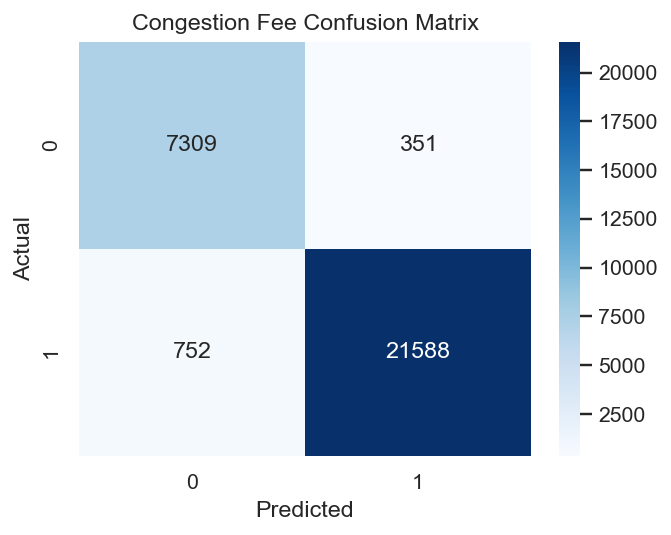

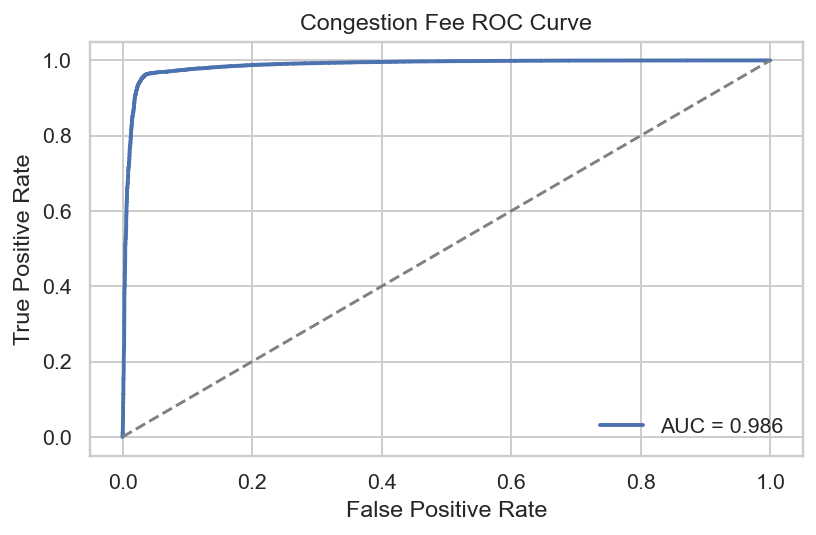

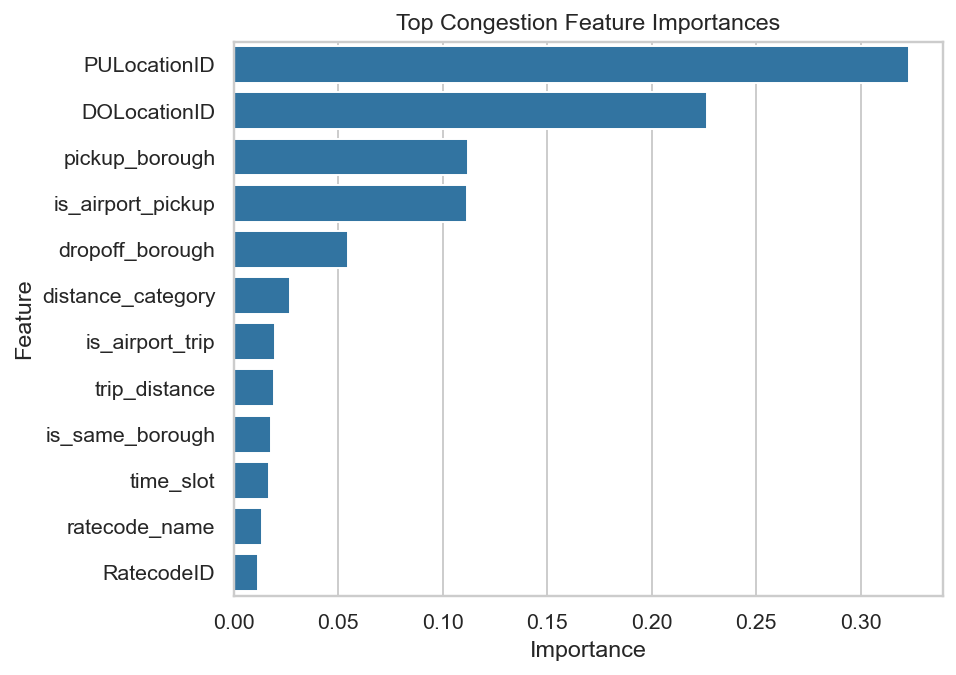

In [6]:
congestion_prob = congestion_xgb.predict_proba(X_test_c)[:, 1]
congestion_pred = (congestion_prob >= 0.50).astype(int)

classification_metrics = {
    "accuracy": float(accuracy_score(y_test_c, congestion_pred)),
    "roc_auc": float(roc_auc_score(y_test_c, congestion_prob)),
    "log_loss": float(log_loss(y_test_c, congestion_prob)),
    "precision": float(precision_score(y_test_c, congestion_pred)),
    "recall": float(recall_score(y_test_c, congestion_pred)),
    "f1": float(f1_score(y_test_c, congestion_pred)),
}

print("Classification metrics:")
for metric_name, metric_value in classification_metrics.items():
    print(f"  {metric_name}: {metric_value:.4f}")

print("\nClassification report:")
print(classification_report(y_test_c, congestion_pred, digits=4))

fpr, tpr, _ = roc_curve(y_test_c, congestion_prob)
classifier_importance = feature_importance_frame(
    congestion_xgb,
    X_congestion.columns,
    top_n=12,
)

print("\nTop congestion features:")
print(classifier_importance.to_string(index=False))

cm = confusion_matrix(y_test_c, congestion_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Congestion Fee Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {classification_metrics['roc_auc']:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("Congestion Fee ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()

plt.figure(figsize=(7, 5))
sns.barplot(
    data=classifier_importance,
    x="importance",
    y="feature",
    orient="h",
    color="#1f77b4",
)
plt.title("Top Congestion Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()


## Trip Duration Regression

The regressor predicts `trip_duration_min` using the same engineered sample while removing
post-trip leakage and the congestion classification target.


In [7]:
X_duration, y_duration, duration_categorical_columns = prepare_features(
    frame=model_data,
    target_name="trip_duration_min",
    extra_drop_columns=["has_congestion_fee"],
)

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_duration,
    y_duration,
    test_size=0.20,
    random_state=SEED,
)
X_train_d, X_val_d, y_train_d, y_val_d = train_test_split(
    X_train_d,
    y_train_d,
    test_size=0.20,
    random_state=SEED,
)

print(f"Regression feature matrix: {X_duration.shape}")
print(f"Regression train/validation/test: {X_train_d.shape}, {X_val_d.shape}, {X_test_d.shape}")
print(f"Categorical columns ({len(duration_categorical_columns)}): {duration_categorical_columns}")


Regression feature matrix: (150000, 21)
Regression train/validation/test: (96000, 21), (24000, 21), (30000, 21)
Categorical columns (11): ['DOLocationID', 'PULocationID', 'RatecodeID', 'distance_category', 'dropoff_borough', 'pickup_borough', 'pickup_day_of_week', 'pickup_hour', 'ratecode_name', 'time_of_day', 'time_slot']


In [8]:
duration_xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.80,
    colsample_bytree=0.80,
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",
    enable_categorical=True,
    early_stopping_rounds=30,
    random_state=SEED,
    n_jobs=-1,
)

duration_xgb.fit(
    X_train_d,
    y_train_d,
    eval_set=[(X_val_d, y_val_d)],
    verbose=False,
)

print(f"Best regressor iteration: {duration_xgb.best_iteration}")
print(f"Best validation RMSE: {float(duration_xgb.best_score):.4f}")


Best regressor iteration: 423
Best validation RMSE: 3.9157


Regression metrics:
  mae: 2.5020
  rmse: 3.8964
  r2: 0.8655

Top trip-duration features:
            feature  importance
is_extreme_distance    0.382440
  distance_category    0.294999
      trip_distance    0.165103
    is_same_borough    0.079670
         is_weekend    0.013755
          time_slot    0.011343
    is_airport_trip    0.008990
       DOLocationID    0.008135
       PULocationID    0.005681
    dropoff_borough    0.005243
        pickup_hour    0.005139
     pickup_borough    0.003766


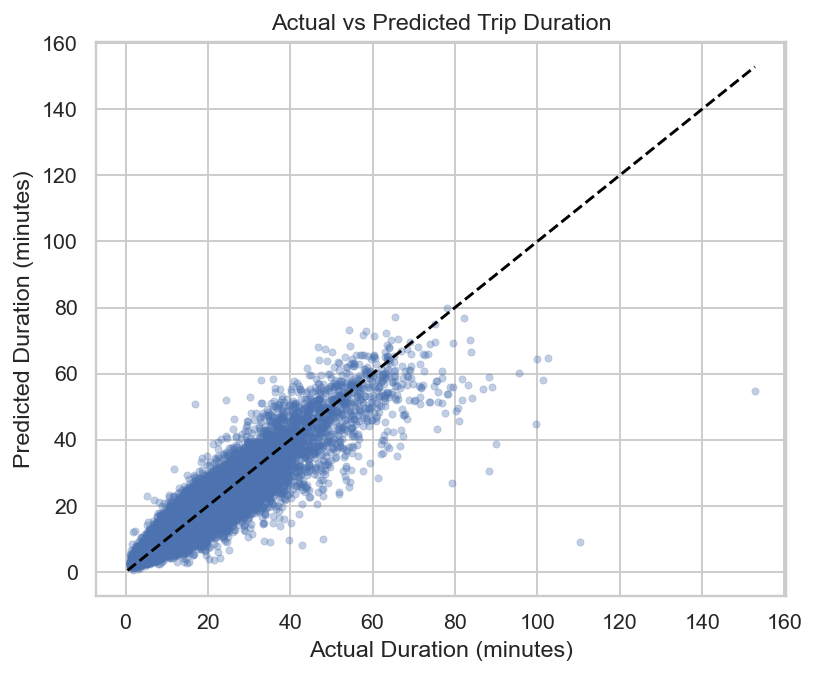

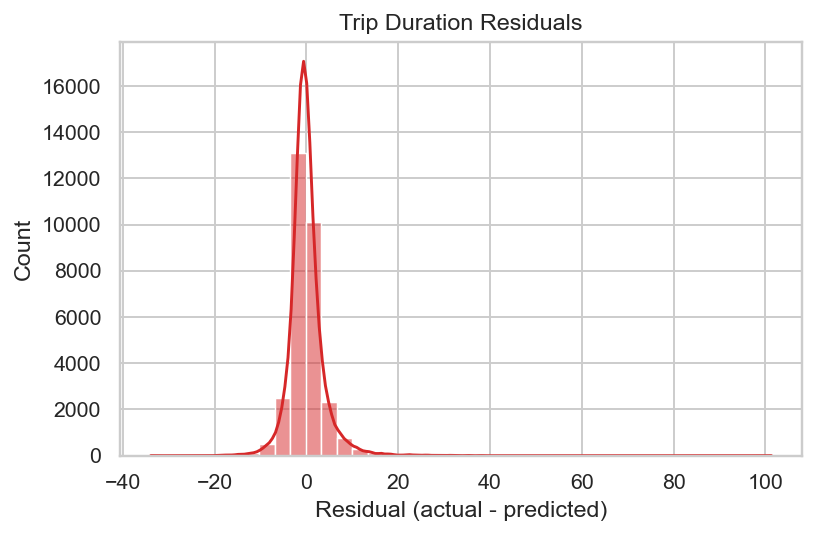

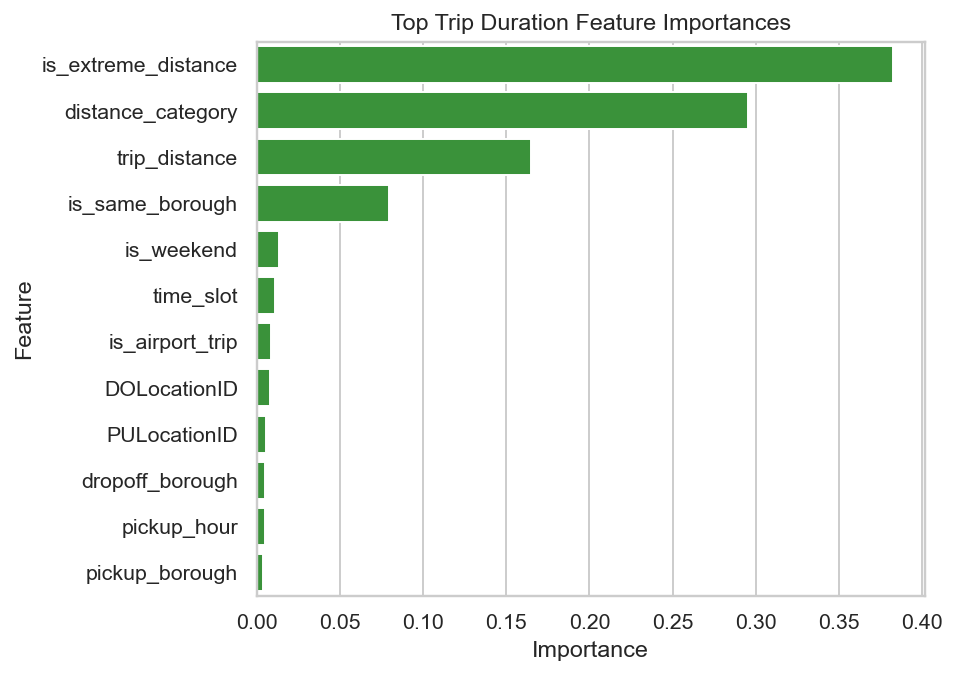

In [9]:
duration_pred = duration_xgb.predict(X_test_d)
residuals = y_test_d - duration_pred

regression_metrics = {
    "mae": float(mean_absolute_error(y_test_d, duration_pred)),
    "rmse": float(np.sqrt(mean_squared_error(y_test_d, duration_pred))),
    "r2": float(r2_score(y_test_d, duration_pred)),
}

print("Regression metrics:")
for metric_name, metric_value in regression_metrics.items():
    print(f"  {metric_name}: {metric_value:.4f}")

regressor_importance = feature_importance_frame(
    duration_xgb,
    X_duration.columns,
    top_n=12,
)

print("\nTop trip-duration features:")
print(regressor_importance.to_string(index=False))

plt.figure(figsize=(6, 5))
sns.scatterplot(x=y_test_d, y=duration_pred, s=14, alpha=0.35, edgecolor=None)
diagonal_min = min(float(y_test_d.min()), float(duration_pred.min()))
diagonal_max = max(float(y_test_d.max()), float(duration_pred.max()))
plt.plot([diagonal_min, diagonal_max], [diagonal_min, diagonal_max], linestyle="--", color="black")
plt.title("Actual vs Predicted Trip Duration")
plt.xlabel("Actual Duration (minutes)")
plt.ylabel("Predicted Duration (minutes)")
plt.tight_layout()

plt.figure(figsize=(6, 4))
sns.histplot(residuals, bins=40, kde=True, color="#d62728")
plt.title("Trip Duration Residuals")
plt.xlabel("Residual (actual - predicted)")
plt.tight_layout()

plt.figure(figsize=(7, 5))
sns.barplot(
    data=regressor_importance,
    x="importance",
    y="feature",
    orient="h",
    color="#2ca02c",
)
plt.title("Top Trip Duration Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()


In [10]:
summary_payload = {
    "sample_size": int(len(model_data)),
    "classification": {
        "best_iteration": int(congestion_xgb.best_iteration),
        "validation_log_loss": float(congestion_xgb.best_score),
        **classification_metrics,
    },
    "regression": {
        "best_iteration": int(duration_xgb.best_iteration),
        "validation_rmse": float(duration_xgb.best_score),
        **regression_metrics,
    },
}

with METRICS_PATH.open("w", encoding="utf-8") as metrics_file:
    json.dump(summary_payload, metrics_file, indent=2)

print("Saved metrics summary:")
print(json.dumps(summary_payload, indent=2))


Saved metrics summary:
{
  "sample_size": 150000,
  "classification": {
    "best_iteration": 191,
    "validation_log_loss": 0.11453093902566858,
    "accuracy": 0.9632333333333334,
    "roc_auc": 0.9863164954851558,
    "log_loss": 0.1116035463102254,
    "precision": 0.9840010939422945,
    "recall": 0.966338406445837,
    "f1": 0.9750897716750604
  },
  "regression": {
    "best_iteration": 423,
    "validation_rmse": 3.915721998798783,
    "mae": 2.5019757747650146,
    "rmse": 3.896414987046649,
    "r2": 0.8655382394790649
  }
}
